Create a visual of CA coastline and the Secchi depths for a Spring Cruise with lots of Casts. Include in-situ measured Secchi depths as well as estimated Secchi depths from our RF for the Casts that have missing Secchi and are in the daylight. 

Color Code:
- Color each point from red to green/purple as shallowest Secchi depth to deepest Secchi depth
- Include a marker to distinguish measured vs estimated Secchi depths

In [14]:
import pandas as pd
daylight = pd.read_parquet("../Data/Parquet/daylight_satellite_all_predictions.parquet")
daylight.head(15)
print(daylight.shape)
df2 = pd.read_parquet('../Data/Parquet/New_estchlsummed.parquet')
print(df2.shape)

(535, 17)
(1971, 43)


The daylight predictions dataset increases our data by 535 / 1971 = 27%. So overall > 25%.

In [15]:
print(f"Distinct Cruise's in daylight: {daylight['Cruise'].nunique()}")
print(daylight['Cruise'].unique())

cast_counts_per_id = daylight.groupby('Cruise')['CAST_COUNT'].nunique()

print(f"\nUnique CAST_COUNTs per Cruise:")
for n_casts, count in cast_counts_per_id.value_counts().sort_index(ascending=False).items():
    cruises = cast_counts_per_id[cast_counts_per_id == n_casts].index.tolist()
    cruise_info = []
    for cruise in cruises:
        subset = daylight[daylight['Cruise'] == cruise]['DATE_TIME_PST']
        cruise_info.append(f"{cruise} ({subset.min()[:10]} to {subset.max()[:10]})")
    print(f"  {n_casts:>2} casts — {count} cruise(s): {', '.join(cruise_info)}")

Distinct Cruise's in daylight: 66
[199910 200001 200104 200107 200201 200211 200304 200307 200401 200404
 200411 200501 200504 200507 200602 200604 200607 200610 200701 200704
 200707 200711 200907 200911 201004 201008 201011 201101 201104 201108
 201110 201202 201203 201207 201210 201301 201304 201307 201311 201402
 201404 201407 201411 201501 201504 201507 201511 201601 201604 201607
 201611 201701 201704 201708 201711 201802 201804 201806 201810 201904
 201907 201911 202001 202007 202010 202101]

Unique CAST_COUNTs per Cruise:
  34 casts — 1 cruise(s): 200507 (2005-07-01 to 2005-07-16)
  32 casts — 2 cruise(s): 200504 (2005-04-15 to 2005-04-30), 200607 (2006-07-08 to 2006-07-23)
  23 casts — 1 cruise(s): 200610 (2006-10-21 to 2006-11-02)
  22 casts — 1 cruise(s): 200411 (2004-11-02 to 2004-11-18)
  20 casts — 1 cruise(s): 201804 (2018-04-05 to 2018-04-26)
  19 casts — 2 cruise(s): 200602 (2006-02-03 to 2006-02-18), 200604 (2006-04-01 to 2006-04-17)
  17 casts — 1 cruise(s): 201604 (

The Cruise with the highest amount of Casts (CAST_COUNTs) within it is 34.
The cell below finds the date of that Cruise.

In [16]:
cruise_cast_counts = daylight.groupby('Cruise')['CAST_COUNT'].nunique()
cruise_34 = cruise_cast_counts[cruise_cast_counts == 34].index[0]

subset = daylight[daylight['Cruise'] == cruise_34]['DATE_TIME_PST']
print(f"Cruise: {cruise_34}")
print(f"Start: {subset.min()}")
print(f"End:   {subset.max()}")

Cruise: 200507
Start: 2005-07-01T06:52:35Z
End:   2005-07-16T09:33:21Z


In [17]:
for count in [32, 23, 22, 19]:
    cruises = cruise_cast_counts[cruise_cast_counts == count].index
    for cruise in cruises:
        subset = daylight[daylight['Cruise'] == cruise]['DATE_TIME_PST']
        print(f"Cruise: {cruise} | CAST_COUNTs: {count} | Start: {subset.min()} | End: {subset.max()}")

Cruise: 200504 | CAST_COUNTs: 32 | Start: 2005-04-15T10:03:14Z | End: 2005-04-30T11:04:27Z
Cruise: 200607 | CAST_COUNTs: 32 | Start: 2006-07-08T07:25:06Z | End: 2006-07-23T11:26:38Z
Cruise: 200610 | CAST_COUNTs: 23 | Start: 2006-10-21T07:28:34Z | End: 2006-11-02T09:10:34Z
Cruise: 200411 | CAST_COUNTs: 22 | Start: 2004-11-02T08:54:52Z | End: 2004-11-18T15:13:32Z
Cruise: 200602 | CAST_COUNTs: 19 | Start: 2006-02-03T10:22:10Z | End: 2006-02-18T11:39:44Z
Cruise: 200604 | CAST_COUNTs: 19 | Start: 2006-04-01T08:29:33Z | End: 2006-04-17T10:40:12Z


In [18]:
for cruise in [202010, 201907]:
    cruise_ids = daylight[daylight['Cruise'] == cruise]['Cruise_ID'].unique()
    print(f"Cruise {cruise}: {cruise_ids}")

Cruise 202010: ['2020-10-11-C-33SR']
Cruise 201907: ['2019-07-11-C-32BH']


In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

CRUISE_ID = '2016-01-07-C-33RL' # winter 2016 cruise with 16 estimated casts

# Estimated Secchi (RF predictions — daylight stations)
cruise = (
    daylight[daylight['Cruise_ID'] == CRUISE_ID]
    .dropna(subset=['Predicted_Secchi_RF'])
    .copy()
)
print(f"Estimated stations : {len(cruise)}  "
      f"range: {cruise['Predicted_Secchi_RF'].min():.2f}–{cruise['Predicted_Secchi_RF'].max():.2f} m")

# Observed Secchi (in-situ measurements)
df2 = pd.read_parquet('../Data/Parquet/New_estchlsummed.parquet')
observed = (
    df2[df2['Cruise_ID'] == CRUISE_ID]
    .dropna(subset=['Secchi'])
    .copy()
)
print(f"Observed stations  : {len(observed)}  "
      f"range: {observed['Secchi'].min():.1f}–{observed['Secchi'].max():.1f} m")

# Shared colormap limits across both datasets
vmin = min(cruise['Predicted_Secchi_RF'].min(), observed['Secchi'].min())
vmax = max(cruise['Predicted_Secchi_RF'].max(), observed['Secchi'].max())
print(f"Shared color scale : {vmin:.2f}–{vmax:.2f} m")

# Load Natural Earth 10m land — clipped to a generous bounding box around CA
land = gpd.read_file('../Data/NaturalEarth/ne_10m_land.shp')
land_ca = land.cx[-126:-116, 28:37]
print(f"Land polygons loaded: {len(land_ca)}")

Estimated stations : 16  range: 8.49–25.73 m
Observed stations  : 20  range: 7.0–45.0 m
Shared color scale : 7.00–45.00 m
Land polygons loaded: 5


Saved: ../results/cruise_2016-01-07-C-33RL_secchi_map.png
Saved: ../results/cruise_2016-01-07-C-33RL_secchi_map.pdf


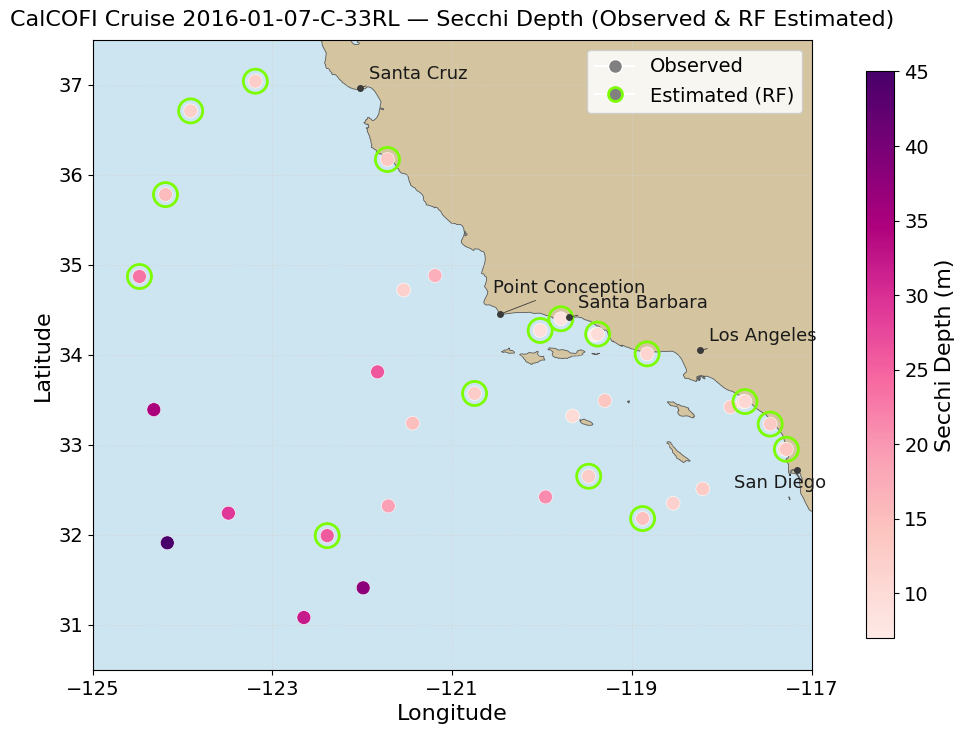

In [22]:
OCEAN   = '#cde5f0'
LAND    = '#d4c5a0'
EDGE    = '#5a5a5a'
LON_EXT = (-125.0, -117.0)
LAT_EXT = (30.5, 37.5)

# Truncate RdPu to skip the near-white low end so shallow stations read as bold red
cmap = mcolors.LinearSegmentedColormap.from_list(
    'RdPu_vivid', plt.cm.RdPu(np.linspace(0.08, 1.0, 256))
)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor(OCEAN)

# Basemap
land_ca.plot(ax=ax, color=LAND, edgecolor=EDGE, linewidth=0.6)

# Observed Secchi points (df2) — plain colored markers, no labels
ax.scatter(
    observed['LON_DEC'], observed['LAT_DEC'],
    c=observed['Secchi'],
    cmap=cmap, vmin=vmin, vmax=vmax,
    s=100, edgecolors='white', linewidths=0.4, zorder=5
)

# Estimated Secchi points (RF predictions) — colored markers + light green ring
sc = ax.scatter(
    cruise['LON_DEC'], cruise['LAT_DEC'],
    c=cruise['Predicted_Secchi_RF'],
    cmap=cmap, vmin=vmin, vmax=vmax,
    s=100, edgecolors='white', linewidths=0.4, zorder=6
)
ax.scatter(
    cruise['LON_DEC'], cruise['LAT_DEC'],
    facecolors='none', edgecolors='#7CFC00', linewidths=2.0,
    s=300, zorder=7
)

# Colorbar
cbar = fig.colorbar(sc, ax=ax, orientation='vertical', pad=0.06, shrink=0.75)
cbar.set_label('Secchi Depth (m)', fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='white', markersize=10, label='Observed'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='#7CFC00', markersize=10, markeredgewidth=2.0, label='Estimated (RF)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=14, framealpha=0.85)

# Landmark labels
landmarks = [
    ('Santa Barbara',    34.42, -119.70, ( 0.10,  0.10)),
    ('Los Angeles',      34.05, -118.24, ( 0.10,  0.10)),
    ('San Diego',        32.72, -117.16, (-0.70, -0.20)),
    ('Point Conception', 34.45, -120.47, (-0.08,  0.24)),
    ('Santa Cruz',       36.97, -122.03, ( 0.10,  0.10)),
]
for name, lat, lon, (dx, dy) in landmarks:
    ax.plot(lon, lat, marker='o', color='#3a3a3a', markersize=4, zorder=8)
    ax.annotate(
        name, xy=(lon, lat), xytext=(lon + dx, lat + dy),
        fontsize=13, color='#1a1a1a',
        arrowprops=dict(arrowstyle='-', color='#3a3a3a', lw=0.6),
        zorder=9
    )

# Extent, labels, title
ax.set_xlim(*LON_EXT)
ax.set_ylim(*LAT_EXT)
ax.set_xlabel('Longitude', fontsize=16)
ax.set_ylabel('Latitude', fontsize=16)
ax.set_title(
    'CalCOFI Cruise 2016-01-07-C-33RL — Secchi Depth (Observed & RF Estimated)',
    fontsize=16, pad=10
)

# Light gridlines
ax.set_xticks(np.arange(-125, -116, 2))
ax.set_yticks(np.arange(31, 38, 1))
ax.grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.6)
ax.tick_params(labelsize=14)

plt.tight_layout()

out_png = '../results/cruise_2016-01-07-C-33RL_secchi_map.png'
out_pdf = '../results/cruise_2016-01-07-C-33RL_secchi_map.pdf'
fig.savefig(out_png, dpi=300, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
print(f"Saved: {out_png}")
print(f"Saved: {out_pdf}")
plt.show()

df2 STA_ID sample:       ['093.3 026.7' '093.3 045.0' '093.3 080.0' '093.3 110.0' '090.0 100.0']
daylight Sta_ID sample:  ['093.3 030.0' '093.3 035.0' '093.3 040.0' '093.3 070.0' '093.3 100.0']
df2 STA_ID dtype:        object
daylight Sta_ID dtype:   object

daylight rows before dedup: 533
daylight rows after dedup:  531
d2 rows:                    1971
combined rows:              2502

pre-Blob: 117 unique stations
Blob: 93 unique stations
post-Blob: 96 unique stations

pre stations:  68,  blob stations: 93
overlap (will produce anomalies): 67
In pre but not blob: ['090.0 045.0']
In blob but not pre: ['070.0 090.0', '080.0 050.5', '066.7 060.0', '093.4 026.4', '063.3 090.0', '063.3 055.0', '073.3 090.0', '090.0 027.7', '088.5 030.1', '091.7 026.4']

Station-season pairs with anomaly: 143
  Winter: 31 stations  |  anomaly -12.9 to 15.9 m
  Spring: 35 stations  |  anomaly -5.6 to 14.2 m
  Summer: 45 stations  |  anomaly -6.5 to 11.1 m
  Fall  : 32 stations  |  anomaly -11.6 to 8.4 m
Sav

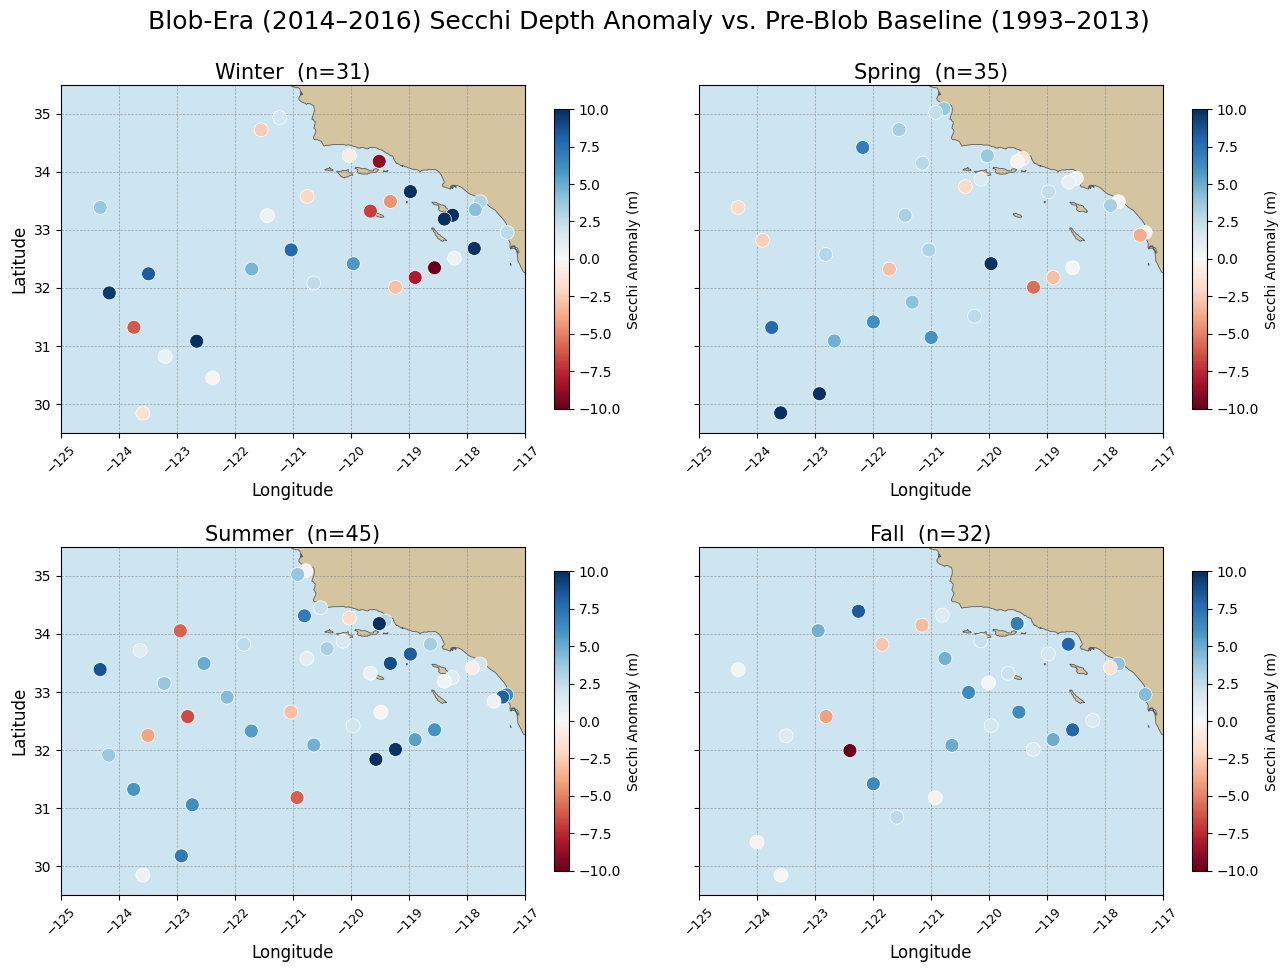

In [23]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# ── season assignment ─────────────────────────────────────────────────────────
def assign_season(month):
    if month in [12, 1, 2]:  return 'Winter'
    if month in [3, 4, 5]:   return 'Spring'
    if month in [6, 7, 8]:   return 'Summer'
    return 'Fall'

# DIAGNOSTIC 1 — check Sta_ID formats
print("df2 STA_ID sample:      ", df2['STA_ID'].dropna().unique()[:5])
print("daylight Sta_ID sample: ", daylight['Sta_ID'].dropna().unique()[:5])
print("df2 STA_ID dtype:       ", df2['STA_ID'].dtype)
print("daylight Sta_ID dtype:  ", daylight['Sta_ID'].dtype)
print()

# ── prep df2: actual Secchi measurements ──────────────────────────────────────
# FIX: df2['LAT_DEC']/['LON_DEC'] use -99 as a sentinel for missing values;
#      Lat_Dec / Lon_Dec hold the true geographic coordinates.
d2 = df2[['Cruise_ID', 'STA_ID', 'Lat_Dec', 'Lon_Dec', 'DATE_TIME_UTC', 'Secchi']].copy()
d2.columns = ['Cruise_ID', 'Sta_ID', 'Lat', 'Lon', 'Date_raw', 'Secchi_combined']
d2['Date']   = pd.to_datetime(d2['Date_raw'])
d2['Month']  = d2['Date'].dt.month
d2['Season'] = d2['Month'].apply(assign_season)
d2 = d2.dropna(subset=['Secchi_combined'])

# ── prep daylight: RF predictions for casts not already in df2 ───────────────
# FIX: two daylight rows carry LAT_DEC ~ -9.99e-29 (sentinel zero); drop them.
dl = (daylight[daylight['LAT_DEC'] > 20]
      [['Cruise_ID', 'Sta_ID', 'LAT_DEC', 'LON_DEC', 'DATE_TIME_UTC', 'Predicted_Secchi_RF']]
      .copy())
dl.columns = ['Cruise_ID', 'Sta_ID', 'Lat', 'Lon', 'Date_raw', 'Secchi_combined']
dl['Date']   = pd.to_datetime(dl['Date_raw'])
dl['Month']  = dl['Date'].dt.month
dl['Season'] = dl['Month'].apply(assign_season)
dl = dl.dropna(subset=['Secchi_combined'])

dl_before = dl.copy()
d2_keys = d2[['Cruise_ID', 'Sta_ID']].drop_duplicates().assign(_flag=True)
dl = dl.merge(d2_keys, on=['Cruise_ID', 'Sta_ID'], how='left')
dl = dl[dl['_flag'].isna()].drop(columns=['_flag'])

# DIAGNOSTIC 2 — how many rows survive deduplication
print(f"daylight rows before dedup: {len(dl_before)}")
print(f"daylight rows after dedup:  {len(dl)}")
print(f"d2 rows:                    {len(d2)}")

# ── combine and label periods ─────────────────────────────────────────────────
keep = ['Cruise_ID', 'Sta_ID', 'Lat', 'Lon', 'Date', 'Season', 'Secchi_combined']
combined = pd.concat([d2[keep], dl[keep]], ignore_index=True)

combined['Period'] = 'post-Blob'
combined.loc[combined['Date'] < '2014-01-01', 'Period'] = 'pre-Blob'
combined.loc[
    (combined['Date'] >= '2014-01-01') & (combined['Date'] <= '2016-12-31'),
    'Period'
] = 'Blob'

print(f"combined rows:              {len(combined)}")
print()

# DIAGNOSTIC 3 — how many unique stations per period
for p in ['pre-Blob', 'Blob', 'post-Blob']:
    print(f"{p}: {combined[combined['Period']==p]['Sta_ID'].nunique()} unique stations")
print()

# ── aggregate mean Secchi per station x season x period ──────────────────────
agg = (
    combined
    .groupby(['Sta_ID', 'Season', 'Period'])
    .agg(
        Mean_Secchi=('Secchi_combined', 'mean'),
        N=('Secchi_combined', 'count'),
        Lat=('Lat', 'mean'),
        Lon=('Lon', 'mean'),
    )
    .reset_index()
)

# pre-Blob baseline: >= 5 observed or estimated depths (1993-2013)
pre = (
    agg[(agg['Period'] == 'pre-Blob') & (agg['N'] >= 5)]
    [['Sta_ID', 'Season', 'Mean_Secchi', 'Lat', 'Lon']]
    .rename(columns={'Mean_Secchi': 'Baseline'})
)

# Blob period: any observations (2014-2016)
blob = (
    agg[agg['Period'] == 'Blob']
    [['Sta_ID', 'Season', 'Mean_Secchi']]
    .rename(columns={'Mean_Secchi': 'Blob_Mean'})
)

# DIAGNOSTIC 4 — pre vs blob station overlap
pre_stations  = set(pre['Sta_ID'].unique())
blob_stations = set(blob['Sta_ID'].unique())
print(f"pre stations:  {len(pre_stations)},  blob stations: {len(blob_stations)}")
print(f"overlap (will produce anomalies): {len(pre_stations & blob_stations)}")
if pre_stations - blob_stations:
    print("In pre but not blob:", list(pre_stations - blob_stations)[:10])
if blob_stations - pre_stations:
    print("In blob but not pre:", list(blob_stations - pre_stations)[:10])
print()

# anomaly = Blob mean - pre-Blob baseline (mean 2014-2016 minus mean 1993-2013)
anomaly_df = pre.merge(blob, on=['Sta_ID', 'Season'])
anomaly_df['Anomaly'] = anomaly_df['Blob_Mean'] - anomaly_df['Baseline']

print(f"Station-season pairs with anomaly: {len(anomaly_df)}")
for s in ['Winter', 'Spring', 'Summer', 'Fall']:
    sub = anomaly_df[anomaly_df['Season'] == s]
    if len(sub):
        print(f"  {s:6s}: {len(sub):2d} stations  |  "
              f"anomaly {sub['Anomaly'].min():.1f} to {sub['Anomaly'].max():.1f} m")

# ── 2x2 seasonal anomaly map ──────────────────────────────────────────────────
OCEAN    = '#cde5f0'
LAND     = '#d4c5a0'
EDGE     = '#5a5a5a'
LON_EXT  = (-125.0, -117.0)
LAT_EXT  = (29.5, 35.5)
SEASONS  = ['Winter', 'Spring', 'Summer', 'Fall']

# 1-degree tick positions for both axes
lon_ticks = np.arange(-125, -116, 1)
lat_ticks = np.arange(30, 36, 1)

# fixed symmetric scale: -10 to +10 m
norm     = mcolors.TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
cmap_div = plt.cm.RdBu   # red = negative anomaly, blue = positive

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
fig.patch.set_facecolor('white')
plt.subplots_adjust(left=0.08, right=0.95, top=0.96, bottom=0.07, hspace=0.08, wspace=0.10)

for i, (ax, season) in enumerate(zip(axes, SEASONS)):
    ax.set_facecolor(OCEAN)

    land_ca.plot(ax=ax, color=LAND, edgecolor=EDGE, linewidth=0.6)

    sub = anomaly_df[anomaly_df['Season'] == season]
    if len(sub) > 0:
        sc = ax.scatter(
            sub['Lon'], sub['Lat'],
            c=sub['Anomaly'],
            cmap=cmap_div, norm=norm,
            s=100, edgecolors='white', linewidths=0.5, zorder=5,
        )
        fig.colorbar(sc, ax=ax, label='Secchi Anomaly (m)', shrink=0.7)

    ax.set_xlim(*LON_EXT)
    ax.set_ylim(*LAT_EXT)
    ax.set_title(f'{season}  (n={len(sub)})', fontsize=15, pad=4)
    ax.set_xlabel('Longitude', fontsize=12)
    if i % 2 == 0:
        ax.set_ylabel('Latitude', fontsize=12)
    else:
        ax.set_yticklabels([])
    ax.set_xticks(lon_ticks)
    ax.set_yticks(lat_ticks)
    ax.tick_params(axis='x', labelsize=9, rotation=45)
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(True, color='grey', linestyle='--', linewidth=0.5, alpha=0.7)

fig.suptitle(
    'Blob-Era (2014–2016) Secchi Depth Anomaly vs. Pre-Blob Baseline (1993–2013)',
    fontsize=18, y=0.995,
)

out_png = '../results/blob_anomaly_2x2.png'
fig.savefig(out_png, dpi=300, bbox_inches='tight')
print(f"Saved: {out_png}")

plt.show()

In [21]:
print(cruise[['Sta_ID', 'LAT_DEC', 'LON_DEC']].to_string(index=False))

     Sta_ID  LAT_DEC    LON_DEC
093.4 026.4 32.94422 -117.27825
091.7 026.4 33.24374 -117.46517
090.0 110.0 30.75121 -123.33012
090.0 070.0 32.08438 -120.63908
086.7 045.0 33.48976 -119.31880
076.7 060.0 34.72118 -121.54856
081.7 043.5 34.40298 -119.81120


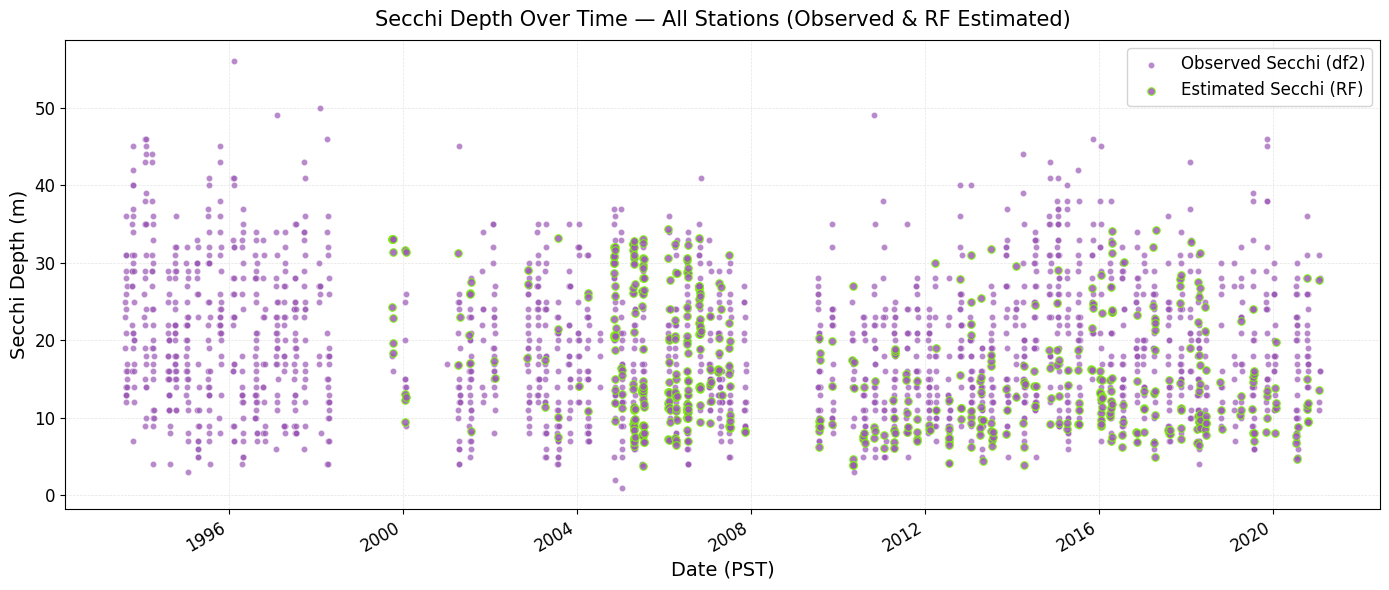

In [34]:
daylight_plot = daylight.dropna(subset=['Predicted_Secchi_RF']).copy()
daylight_plot['date_pst'] = pd.to_datetime(daylight_plot['DATE_TIME_PST'], utc=True)

df2_plot = df2.dropna(subset=['Secchi']).copy()
df2_plot['date_pst'] = pd.to_datetime(df2_plot['DATE_TIME_PST'], utc=True)

fig, ax = plt.subplots(figsize=(14, 6))

# Observed Secchi (df2) — plain markers
ax.scatter(
    df2_plot['date_pst'], df2_plot['Secchi'],
    s=20, color='#9b59b6', edgecolors='white', linewidths=0.3,
    alpha=0.7, zorder=4, label='Observed Secchi (df2)'
)

# Estimated Secchi (daylight RF) — light green outline
ax.scatter(
    daylight_plot['date_pst'], daylight_plot['Predicted_Secchi_RF'],
    s=30, color='#9b59b6', edgecolors='#7CFC00', linewidths=0.8,
    alpha=0.85, zorder=5, label='Estimated Secchi (RF)'
)

ax.set_xlabel('Date (PST)', fontsize=14)
ax.set_ylabel('Secchi Depth (m)', fontsize=14)
ax.set_title('Secchi Depth Over Time — All Stations (Observed & RF Estimated)', fontsize=15, pad=10)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12, framealpha=0.85)
ax.grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

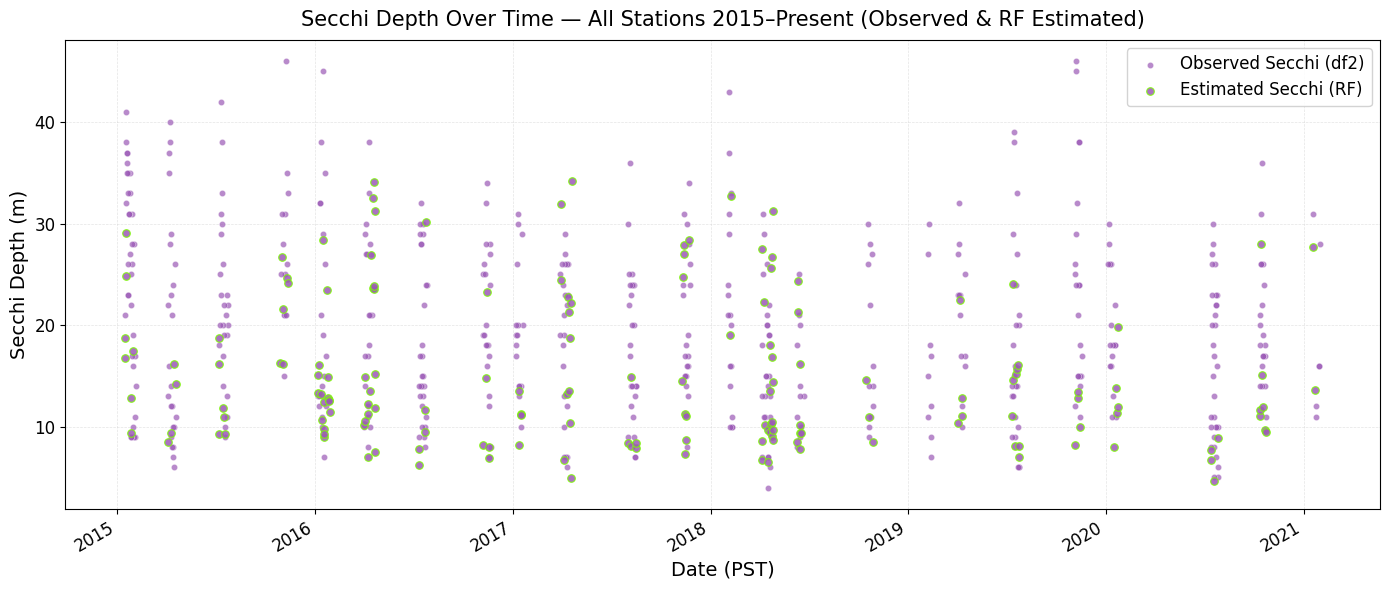

In [35]:
cutoff = pd.Timestamp('2015-01-01', tz='UTC')
df2_recent   = df2_plot[df2_plot['date_pst'] >= cutoff]
day_recent   = daylight_plot[daylight_plot['date_pst'] >= cutoff]

fig, ax = plt.subplots(figsize=(14, 6))

ax.scatter(
    df2_recent['date_pst'], df2_recent['Secchi'],
    s=20, color='#9b59b6', edgecolors='white', linewidths=0.3,
    alpha=0.7, zorder=4, label='Observed Secchi (df2)'
)
ax.scatter(
    day_recent['date_pst'], day_recent['Predicted_Secchi_RF'],
    s=30, color='#9b59b6', edgecolors='#7CFC00', linewidths=0.8,
    alpha=0.85, zorder=5, label='Estimated Secchi (RF)'
)

ax.set_xlabel('Date (PST)', fontsize=14)
ax.set_ylabel('Secchi Depth (m)', fontsize=14)
ax.set_title('Secchi Depth Over Time — All Stations 2015–Present (Observed & RF Estimated)', fontsize=15, pad=10)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12, framealpha=0.85)
ax.grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()